# Machine Learning model to predict LTV of a customer

#### This Machine learning model will be able to predict the amount of time a person will be a customer for and predict how much they will spend allowing a company to tailor there cost of acquisition to a customer allowing them to maximise the Lifetime value of a customer (LTV - CAAC)

## Environment

In [34]:
import pandas as pd
import pycaret as py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pycaret.regression import *
import pycaret.classification as clf
import xgboost as xgboost
import pycaret.regression as reg
import shap

# Loading data 
The data transactional data use is from 01/12/2010 and 09/12/2011 and it is from a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

In [35]:
transactions = pd.read_csv('Ecommerce_data.csv', encoding='latin')
transactions.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 8:26,3.39,17850.0,United Kingdom


# Data Exploration / Analysis and correction of errors

In [36]:
transactions.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [37]:
# taking out any incorrect data entry
transactions=transactions.loc[transactions['UnitPrice']>0]
transactions=transactions.loc[transactions['Quantity']>0]


In [38]:
# formatting the date column
transactions['InvoiceDate']=pd.to_datetime(transactions['InvoiceDate'])
transactions['month'] = transactions['InvoiceDate'].dt.month
transactions['year'] = transactions['InvoiceDate'].dt.year
transactions.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,month,year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010


In [39]:
# Roughly a years worth of data has been gathered
transactions['InvoiceDate']=pd.to_datetime(transactions['InvoiceDate'])
print(transactions['InvoiceDate'].min())
print(transactions['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


## Sales were around the 700-800k for January - August and then increase to 1 million for September to December 

         Date  month  year        Sales
0  2010-12-01     12  2010   823746.140
1  2011-01-01      1  2011   691364.560
2  2011-02-01      2  2011   523631.890
3  2011-03-01      3  2011   717639.360
4  2011-04-01      4  2011   537808.621
5  2011-05-01      5  2011   770536.020
6  2011-06-01      6  2011   761739.900
7  2011-07-01      7  2011   719221.191
8  2011-08-01      8  2011   759138.380
9  2011-09-01      9  2011  1058590.172
10 2011-10-01     10  2011  1154979.300
11 2011-11-01     11  2011  1509496.330
12 2011-12-01     12  2011   638792.680


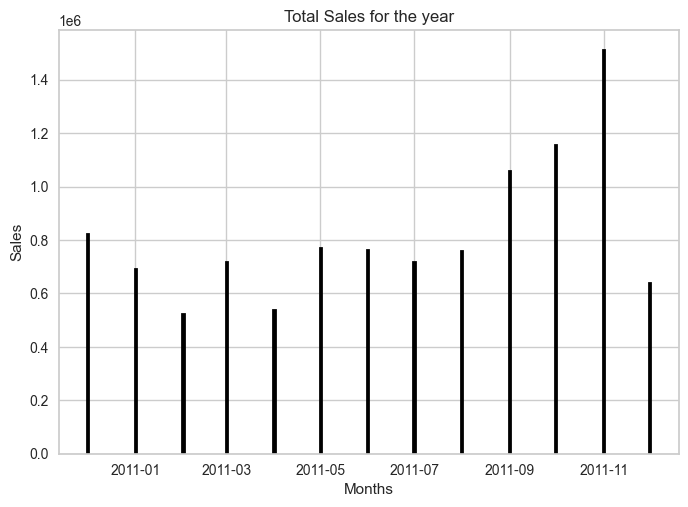

In [40]:
# Sales accross the year
transactions['Sales']=transactions['Quantity']*transactions['UnitPrice']

total_monthly_sales=transactions.groupby(['month','year']).agg({'Sales':'sum'})
total_monthly_sales=total_monthly_sales.reset_index()
total_monthly_sales['Date'] = pd.to_datetime(total_monthly_sales[['year', 'month']].assign(day=1))
total_monthly_sales=total_monthly_sales.groupby(['Date']).agg('sum').reset_index()

sum_monthly_sales=total_monthly_sales[['Sales','Date']]
print(total_monthly_sales)


plt.bar(sum_monthly_sales['Date'],sum_monthly_sales['Sales'],linewidth=2.0,edgecolor='black')
plt.title('Total Sales for the year')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.show()

# Customers
## There are 4338 unique customers and a total of 397884 transactions with Customer IDs and 132220 without CustomerID. There are a total of 530,104 transactions


In [41]:
print(transactions['CustomerID'].nunique())
print(transactions['CustomerID'].count())
print((transactions['CustomerID'].isnull()).count())

4338
397884
530104


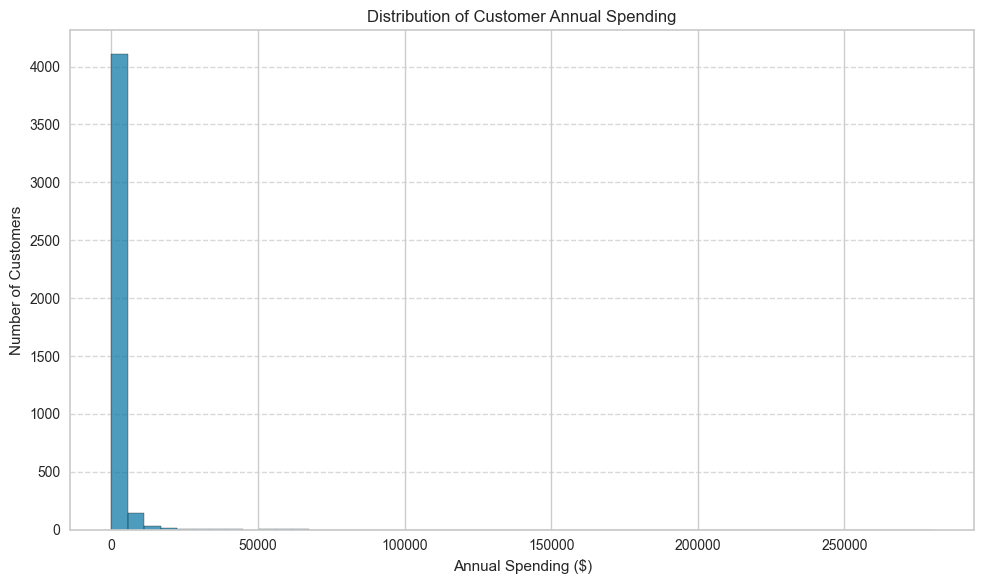

In [42]:
cust_trans=transactions[['Sales','CustomerID']].groupby(['CustomerID']).agg('sum').sort_values('Sales')
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(cust_trans, bins=50, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Annual Spending ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Annual Spending')

# Add grid for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()

In [43]:
cust_trans.loc[cust_trans['Sales']>20000]

,Sales
CustomerID,
17381.0,20275.61
17675.0,20374.28
16210.0,21086.30
12744.0,21279.29
12753.0,21429.39
13777.0,25977.16
16333.0,26626.80
17857.0,26879.04
13408.0,28117.04


In [44]:
Due to the lar

# cust_trans=cust_trans.reset_index()
cust_spec=cust_trans.loc[cust_trans['Sales']<20000]
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(cust_spec, bins=50, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Annual Spending ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Annual Spending')

# Add grid for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (2443369607.py, line 1)

In [ ]:
# Item quantity sold
# largest quantity of items sold
item_quant=transactions.groupby(['Description']).agg({'Quantity':'sum'}).reset_index()
item_quant=item_quant.sort_values('Quantity')
top_sales=item_quant.tail(10)
print(top_sales)

                             Description  Quantity
2107             MINI PAINT SET VINTAGE      26633
2741                  RABBIT NIGHT LIGHT     30788
2337     PACK OF 72 RETROSPOT CAKE CASES     36419
227        ASSORTED COLOUR BIRD ORNAMENT     36461
2681                      POPCORN HOLDER     36761
3844  WHITE HANGING HEART T-LIGHT HOLDER     37891
1816             JUMBO BAG RED RETROSPOT     48474
3934   WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
2052      MEDIUM CERAMIC TOP STORAGE JAR     78033
2387         PAPER CRAFT , LITTLE BIRDIE     80995


# The Vast majority of transactions come from UK (91.5%)

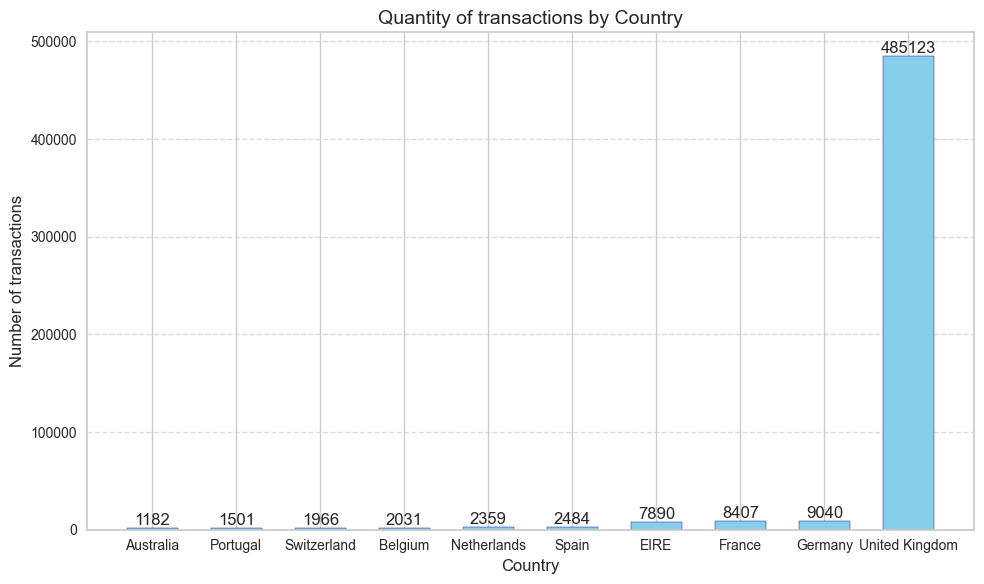

In [ ]:
trans_by_country=transactions.groupby(['Country']).agg({'Country':'count'})
trans_by_country=trans_by_country.rename(columns={'Country':'Quantity'})
trans_ranks_count=trans_by_country.sort_values('Quantity').tail(10).reset_index()


plt.figure(figsize=(10, 6))
bars = plt.bar(height=trans_ranks_count['Quantity'],x=trans_ranks_count['Country'], color='skyblue', edgecolor='navy', width=0.6)

# Add title and labels
plt.title('Quantity of transactions by Country', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of transactions', fontsize=12)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height}', ha='center', va='bottom')

# Add grid lines for the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Customize appearance
plt.tight_layout()
plt.show()

# Using the ML algorithm to understand the expected LTV of customers

Lifetime Value of customers is the future value of the customer, which can be seperated into

- will they Churn? (Classification)
 
- what is the expected customer spend of the customer? (Regression)

2 different models will be used to predict whether they will churn and what will be the value of there spend. This knowledge will be used to prioritise marketing spend into "saving customers", allowing promotional spend to be less then the expected future spend of customers.

# Step 1 - Defining the problems and the parameters of the model
a) Define Churn:
We will define churn as a customer not having purchased a good for 90 days

b) Seperate the historical (Training Data) and the testing data as to be able to quantify the accuracy of the model






In [ ]:
n_days = 90
max_date=transactions['InvoiceDate'].max()
cutoff= max_date-pd.to_timedelta(n_days, unit="d")
 # train-test Split- temporal out df relates to the actual amount of expenditure in the next 90 days after the target date

In [ ]:
cutoff

Timestamp('2011-09-10 12:50:00')

# This is the seperation of data into 80% and 20% to be able to predict- this will be worked out later

In [ ]:
# # 1. Sample the data, but keep the original index
# trans_seen = transactions.sample(frac=0.9, random_state=786)

# # 2. Get the index of the sampled rows (this is the original index)
# sampled_indices = trans_seen.index

# # 3. Reset the index of trans_seen (this is fine now)
# trans_seen = trans_seen.reset_index(drop=True)

# # 4. Drop the sampled rows from the original transactions using the original index
# trans_unseen = transactions.drop(sampled_indices).reset_index(drop=True)

# print('Data for Modeling: ' + str(trans_seen.shape))
# print('Unseen Data For Predictions: ' + str(trans_unseen.shape))

## Develop targets: To compare the actual vs the predicted
Filtering the out data for customers who only exist in the in data

In [ ]:
temporal_in_df=transactions[transactions['InvoiceDate']< cutoff]
temporal_out_df=transactions[transactions['InvoiceDate'] >=cutoff].query('CustomerID in @temporal_in_df.CustomerID')
targets=temporal_out_df[['CustomerID','Sales']].groupby(['CustomerID']).sum().rename({'Sales':'Sales_90'},axis=1).assign(sales_90_flag=1)

# Step 2: Create  Features which represent the RFM analysis as the basis for the ML model
Recency- when was the last time they made a purchase

Frequency- How many times did they purchase during the period

Monetary Values- What was the total monetary value they spent during the time and what is the average value of the the transactions

As RFM have known relationships between the future value of a customer we will use this as the basis for the ML. In the future we can develop further features which increase the relationship between historical data and the future value.

## Create Recency Features
- The last time they purchased minus the maximum amount of days during the period under analysis

In [ ]:
max_date=temporal_in_df['InvoiceDate'].max()
recency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').apply(lambda x: int((x['InvoiceDate'].max()-max_date)/pd.to_timedelta(1,"day"))).to_frame()
recency_features_df=recency_features_df.rename(columns={0:'Recency'})
recency_features_df.head()

,Recency
CustomerID,
12346.0,-234
12347.0,-38
12348.0,-157
12350.0,-219
12352.0,-171


In [93]:
temporal_in_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,month,year,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
...,...,...,...,...,...,...,...,...,...,...,...
334047,566221,22379,RECYCLING BAG RETROSPOT,5,2011-09-09 16:13:00,2.10,NaN,United Kingdom,9,2011,10.50
334048,566221,21932,SCANDINAVIAN PAISLEY PICNIC BAG,4,2011-09-09 16:13:00,1.65,NaN,United Kingdom,9,2011,6.60
334049,566221,21933,PINK VINTAGE PAISLEY PICNIC BAG,3,2011-09-09 16:13:00,1.65,NaN,United Kingdom,9,2011,4.95
334052,566224,21928,JUMBO BAG SCANDINAVIAN BLUE PAISLEY,3,2011-09-09 17:52:00,2.08,NaN,United Kingdom,9,2011,6.24


In [94]:
temporal_in_df.loc[temporal_in_df['CustomerID']==17850.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,month,year,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
...,...,...,...,...,...,...,...,...,...,...,...
4540,536790,22752,SET 7 BABUSHKA NESTING BOXES,4,2010-12-02 15:26:00,7.65,17850.0,United Kingdom,12,2010,30.60
4541,536790,22803,IVORY EMBROIDERED QUILT,3,2010-12-02 15:26:00,35.75,17850.0,United Kingdom,12,2010,107.25
4542,536790,21730,GLASS STAR FROSTED T-LIGHT HOLDER,12,2010-12-02 15:26:00,4.25,17850.0,United Kingdom,12,2010,51.00
4543,536791,22632,HAND WARMER RED POLKA DOT,12,2010-12-02 15:27:00,1.85,17850.0,United Kingdom,12,2010,22.20


In [100]:
max_date

Timestamp('2011-09-09 17:52:00')

In [101]:
temporal_in_df['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
334047   2011-09-09 16:13:00
334048   2011-09-09 16:13:00
334049   2011-09-09 16:13:00
334052   2011-09-09 17:52:00
334053   2011-09-09 17:52:00
Name: InvoiceDate, Length: 326189, dtype: datetime64[ns]

# Create Frequency Features
- The number of times in which they purchased over the period under analysis

In [ ]:
frequency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').count()
frequency_features_df=frequency_features_df.rename(columns={'InvoiceDate':'Frequency'})
frequency_features_df.head()

,Frequency
CustomerID,
12346.0,1
12347.0,124
12348.0,28
12350.0,17
12352.0,38


# Create Monetary Value Features
- The average sale of each transactions and the total sales during the period of historical sales


In [ ]:
monetary_features=temporal_in_df.groupby(['CustomerID']).agg({'Sales':['sum','mean']}).set_axis(['sales_value_sum','sales_values_mean'],axis=1)
print(monetary_features)

            sales_value_sum  sales_values_mean
CustomerID                                    
12346.0            77183.60       77183.600000
12347.0             2790.86          22.506935
12348.0             1487.24          53.115714
12350.0              334.40          19.670588
12352.0             1561.81          41.100263
...                     ...                ...
18280.0              180.60          18.060000
18281.0               80.82          11.545714
18282.0              100.21          14.315714
18283.0             1120.67           2.507092
18287.0              765.28          26.388966

[3370 rows x 2 columns]


# Create A 14 day off Cutoff as a feature
This will be an added feature which will help develop the future probability of LTV. As a customer who has purchased within the last 14 days, is a greater 

In [ ]:
cut_off_14d= cutoff-pd.to_timedelta(14,unit="d")

sales_last_2weeks_df=temporal_in_df.query('InvoiceDate >= @cut_off_14d')\
[['CustomerID','Sales']].drop_duplicates()\
.groupby('CustomerID')\
.sum()\
.set_axis(['sales_last_2weeks'],axis=1).fillna(0)
sales_last_2weeks_df.head()

,sales_last_2weeks
CustomerID,
12375.0,150.90
12408.0,438.68
12415.0,2941.72
12422.0,52.30
12423.0,155.80


# Concatinate all the features into the singular dataframe and merge in the targets

In [ ]:
features=pd.concat([recency_features_df, frequency_features_df, monetary_features,sales_last_2weeks_df],axis=1)
features['sales_last_2weeks']=features['sales_last_2weeks'].fillna(0)
features=features.merge(targets,how='left',left_index=True,right_index=True)
features['Sales_90']=features['Sales_90'].fillna(0)
features['sales_90_flag']=features['sales_90_flag'].fillna(0)
features.head()

,Recency,Frequency,sales_value_sum,sales_values_mean,sales_last_2weeks,Sales_90,sales_90_flag
CustomerID,,,,,,,
12346.0,-234,1,77183.60,77183.600000,0.0,0.00,0.0
12347.0,-38,124,2790.86,22.506935,0.0,1519.14,1.0
12348.0,-157,28,1487.24,53.115714,0.0,310.00,1.0
12350.0,-219,17,334.40,19.670588,0.0,0.00,0.0
12352.0,-171,38,1561.81,41.100263,0.0,944.23,1.0


In [ ]:
features['Sales_90'].mean()

846.2532080118693

In [79]:
features

,Recency,Frequency,sales_value_sum,sales_values_mean,sales_last_2weeks,Sales_90,sales_90_flag
CustomerID,,,,,,,
12346.0,-234,1,77183.60,77183.600000,0.00,0.00,0.0
12347.0,-38,124,2790.86,22.506935,0.00,1519.14,1.0
12348.0,-157,28,1487.24,53.115714,0.00,310.00,1.0
12350.0,-219,17,334.40,19.670588,0.00,0.00,0.0
12352.0,-171,38,1561.81,41.100263,0.00,944.23,1.0
...,...,...,...,...,...,...,...
18280.0,-186,10,180.60,18.060000,0.00,0.00,0.0
18281.0,-89,7,80.82,11.545714,0.00,0.00,0.0
18282.0,-35,7,100.21,14.315714,0.00,77.84,1.0


# Regression model for the predictions of the monetary value spent by the customer over the 90 days

In [63]:
reg_setup=reg.setup(
    data=features.drop('sales_90_flag',axis=1),
    target='Sales_90',
    train_size=.8,
    normalize=True,
    session_id=123,
    verbose=True,
    log_experiment=False
)


,Description,Value
0,Session id,123
1,Target,Sales_90
2,Target type,Regression
3,Original data shape,"(3370, 6)"
4,Transformed data shape,"(3370, 6)"
5,Transformed train set shape,"(2696, 6)"
6,Transformed test set shape,"(674, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,simple


In [ ]:
compare_models

# Evaluating the model
MAE: Mean absolute errors, the sum of all the errors (all positives) 
RMSE: The square of all the errors and takes there mean. Increasing the importance of larger error rates and then getting the squared root of the final amount 
R squared: How much the real values differ from the estimates, closer to one the better


In [71]:

xgb_reg_model=reg.create_model('xgboost')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,429.0400,711343.4375,843.4118,-0.4381,3.3603,1.3919
1,528.6376,1740855.7500,1319.4149,0.3968,3.9031,4.5209
2,786.7193,9826901.0000,3134.7888,-0.6877,3.8840,21.0573
3,610.6152,2576537.2500,1605.1595,0.1884,3.5449,1.2339
4,951.2869,35231660.0000,5935.6265,-16.1770,3.8304,1.1327
5,908.1991,23477892.0000,4845.3989,0.4740,3.7160,1.1663
6,1144.8636,106449416.0000,10317.4326,-0.0111,3.8038,0.7804
7,1201.6812,47972640.0000,6926.2285,0.3662,3.3409,0.8986
8,534.3530,2887387.2500,1699.2313,0.9342,3.5500,0.6330


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [77]:
xgb_reg_model

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

In [73]:
reg_prediction_df=reg.predict_model(xgb_reg_model,data= features)\
.sort_values('prediction_label',ascending=False)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,292.3905,2986112.2500,1728.0372,0.8809,3.2164,0.6168


In [62]:
tuned_xgb=tune_model('reg_prediction_df')

TypeError: The behavior of tune_model in version 1.0.1 is changed. Please pass trained model object.

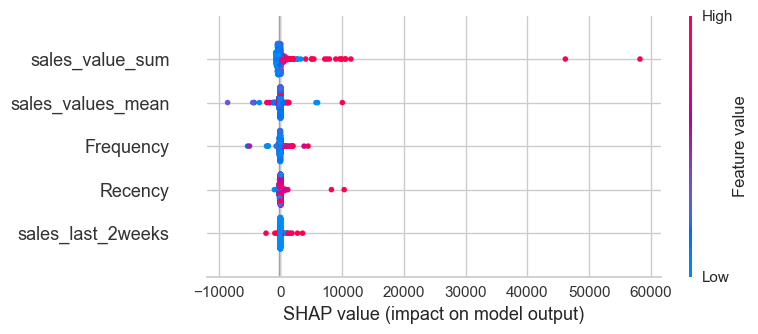

In [53]:
reg.interpret_model(xgb_reg_model)

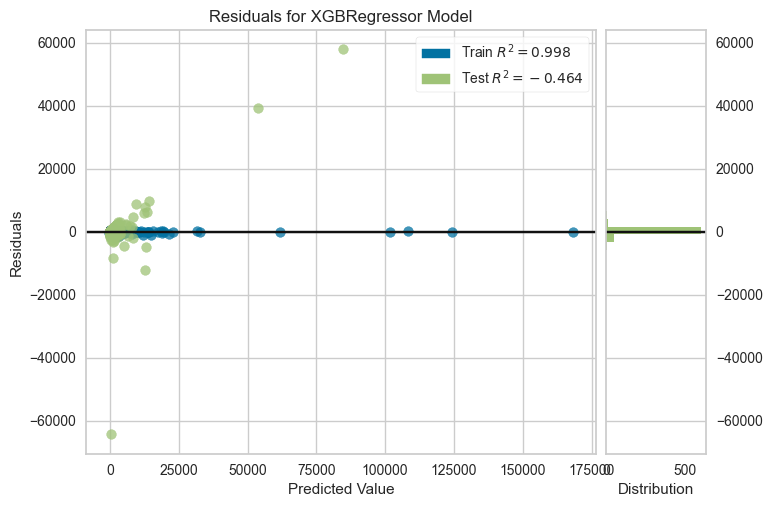

In [60]:
plot_model(xgb_reg_model)

# Classification model on whether they churn or not over the 90 days

In [48]:

# Classification (spend probability)
# have to drop the sales_90_value as that is a precursor to the classification problem of whether they spend or not
clf_setup=clf.setup(
    data=features.drop('Sales_90',axis=1),
    target='sales_90_flag',
    train_size=.8,
    normalize=True,
    verbose=True,
    log_experiment=False
                    )




,Description,Value
0,Session id,405
1,Target,sales_90_flag
2,Target type,Binary
3,Original data shape,"(3370, 6)"
4,Transformed data shape,"(3370, 6)"
5,Transformed train set shape,"(2696, 6)"
6,Transformed test set shape,"(674, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,simple


## Evaluation of classification ML models
Precision: % of correctly labelled positive instance out of all positive labelled instances TP/TP+FP

Recall: % of correctly labelled positives instances out of all positive instances TP/TP+FN

F1 Score: 2/(1/Precision)+(1/Recall)

AUC: Area under the curb, looks at the difference between the True positive and False positive. 

In [49]:
xgb_clf_model=clf.create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6222,0.6875,0.6883,0.6625,0.6752,0.2242,0.2245
1,0.6481,0.6933,0.7143,0.6832,0.6984,0.2767,0.2771
2,0.6407,0.7121,0.6753,0.6887,0.6820,0.2693,0.2694
3,0.6074,0.6529,0.6753,0.6500,0.6624,0.1938,0.1940
4,0.6778,0.7239,0.7143,0.7190,0.7166,0.3432,0.3432
5,0.6333,0.6811,0.7273,0.6627,0.6935,0.2397,0.2413
6,0.6506,0.7135,0.7124,0.6855,0.6987,0.2832,0.2835
7,0.6208,0.6859,0.6928,0.6584,0.6752,0.2205,0.2209
8,0.6877,0.7215,0.7255,0.7255,0.7255,0.3634,0.3634


In [57]:
clf_predictions_df=clf.predict_model(xgb_clf_model,data=features,raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.8866,0.9397,0.8948,0.9052,0.9000,0.7692,0.7693


## 

In [ ]:
print(clf_predictions_df.shape)
print(features.shape)

(3370, 10)
(3370, 7)


In [ ]:
clf.interpret_model(xgb_clf_model)


2922492.8